# Goal

To see how I can improve the data / model used to predict world cup games. The main goal right now is:

1. To see why many matches share 0-2 prediction
2. See why Germany vs Curacao match didn't have as big of a goal difference predicted
3. See why model thought South Africa would beat Mexico e.t.c.

In [1]:
# Imports and constants
import numpy as np
import pandas as pd
from helpers.prediction import uncondense_parameters, f_x, interpret_probabilities, get_feature_to_predict
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy.typing as npt
from datetime import datetime

player_statistics_file = "data/player_statistics_2026-06-15 22:25:30.781664.csv"
squad_members = pd.read_excel('data/World Cup 2026.xlsx', sheet_name="Squad Members")
statistics = pd.read_csv(player_statistics_file)
players = pd.read_excel('data/World Cup 2026.xlsx', sheet_name="Players")

model_weights_concatenated = np.load("parameters/model_V3_parameters_2026-06-12 16:16:55.752520.npy", allow_pickle=True)
mean_std = np.load("parameters/model_v3_mean_std_2026-06-12 16:17:53.057086.npy")

/home/roman/Code/AIEngineering/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


(24, 18)
(24, 2)
0.9619979974830137


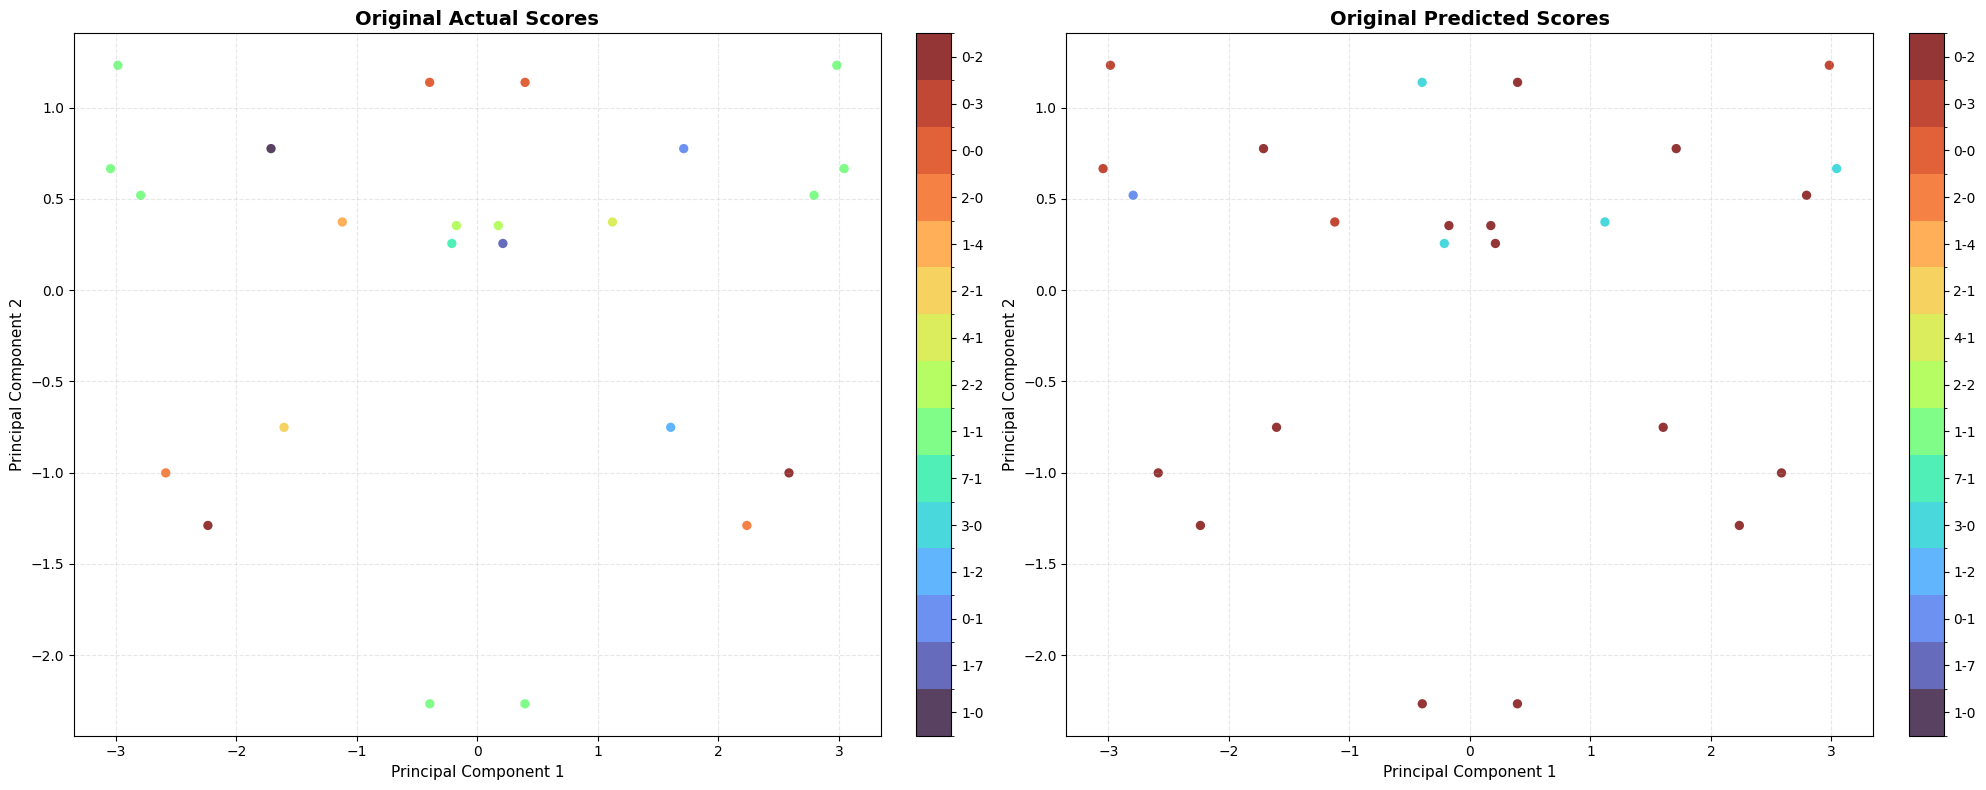

In [2]:
# Visualize the various matches with a scatter plot
squads = 24
original_teams = np.empty((0, 18))

for i in range(0, squads - 1, 2):
    home_squad = i + 1
    away_squad = i + 2
    
    team = get_feature_to_predict(
        mean_std=mean_std,
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        home_squad_id=home_squad,
        away_squad_id= away_squad,
        match_date='2026-06-15'
    )
    team_reversed = get_feature_to_predict(
        mean_std=mean_std,
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        home_squad_id=away_squad,
        away_squad_id= home_squad,
        match_date='2026-06-15'
    )
    original_teams = np.append(original_teams, team.T, axis=0)
    original_teams = np.append(original_teams, team_reversed.T, axis=0)
    
print(original_teams.shape)
pca = PCA(n_components=2)
original_compressed_teams = pca.fit_transform(original_teams)
print(original_compressed_teams.shape)
print(np.sum(pca.explained_variance_ratio_))

predicted_scores = [
    '0-2',
    '0-2',
    '0-2',
    '0-2',
    '0-2',
    '0-2',
    '3-0',
    '0-3',
    '3-0',
    '0-3',
    '0-1',
    '0-2',
    '0-2',
    '0-2',
    '3-0',
    '0-2',
    '0-2',
    '0-2',
    '0-2',
    '0-2',
    '3-0',
    '0-2',
    '0-3',
    '0-3'
]

actual_scores = [
    '2-0',
    '0-2',
    '2-1',
    '1-2',
    '1-1',
    '1-1',
    '4-1',
    '1-4',
    '1-1',
    '1-1',
    '1-1',
    '1-1',
    '0-1',
    '1-0',
    '7-1',
    '1-7',
    '2-0',
    '0-2',
    '2-2',
    '2-2',
    '0-0',
    '0-0',
    '1-1',
    '1-1'
]
total_scores = []
total_scores.extend(predicted_scores)
total_scores.extend(actual_scores)

original_labels = list(set(total_scores))

original_predicted_scores_color_map = [original_labels.index(i) for i in predicted_scores]
original_actual_scores_color_map = [original_labels.index(i) for i in actual_scores]

# Put this block right above your plt.scatter call
original_num_categories = len(original_labels)
original_cmap = plt.get_cmap('turbo', original_num_categories) # Forces the map into distinct steps
original_norm = mcolors.BoundaryNorm(boundaries=range(original_num_categories + 1), ncolors=original_num_categories)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(20, 8))

# ==========================================
# Right PLOT: Predicted Scores (axs[0])
# ==========================================
scatter1 = axs[1].scatter(
    original_compressed_teams[:, 0],
    original_compressed_teams[:, 1],
    c=original_predicted_scores_color_map,
    cmap=original_cmap,
    norm=original_norm,
    alpha=0.8,
    edgecolors="none",
    s=45,  # Slightly larger for visibility
)
axs[1].set_title("Original Predicted Scores", fontsize=14, fontweight="bold")
axs[1].set_xlabel("Principal Component 1", fontsize=11)
axs[1].set_ylabel("Principal Component 2", fontsize=11)
axs[1].grid(True, linestyle="--", alpha=0.3)

# Add the categorical colorbar to the first plot
cbar1 = fig.colorbar(scatter1, ax=axs[1], fraction=0.046, pad=0.04)
cbar1.set_ticks(np.arange(original_num_categories) + 0.5)  # Centers text on color blocks
cbar1.set_ticklabels(original_labels)

# ==========================================
# RIGHT PLOT: Actual Scores (axs[1])
# ==========================================
scatter2 = axs[0].scatter(
    original_compressed_teams[:, 0],
    original_compressed_teams[:, 1],
    c=original_actual_scores_color_map,
    cmap=original_cmap,
    norm=original_norm,
    alpha=0.8,
    edgecolors="none",
    s=45,
)
axs[0].set_title("Original Actual Scores", fontsize=14, fontweight="bold")
axs[0].set_xlabel("Principal Component 1", fontsize=11)
axs[0].set_ylabel("Principal Component 2", fontsize=11)
axs[0].grid(True, linestyle="--", alpha=0.3)

# Add the identical categorical colorbar to the second plot
cbar2 = fig.colorbar(scatter2, ax=axs[0], fraction=0.046, pad=0.04)
cbar2.set_ticks(np.arange(original_num_categories) + 0.5)
cbar2.set_ticklabels(original_labels)

# 3. Clean up spacing and render
plt.tight_layout()
plt.show()

In [3]:
# Store squad ids
class Squads:
    MEXICO = 1
    SOUTH_AFRICA = 2
    SOUTH_KOREA = 3
    CZECH = 4
    CANADA = 5
    BOSNIA = 6
    USA = 7
    PARAGUAY = 8
    QATAR = 9
    SWITZERLAND = 10
    BRAZIL = 11
    MOROCCO = 12
    HAITI = 13
    SCOTLAND = 14
    GERMANY = 15
    CURACAO = 16
    AUSTRALIA = 17
    TURKIYE = 18
    NETHRELANDS = 19
    JAPAN = 20
    SPAIN = 21
    CAPE_VERDE = 22,
    BELGIUM = 23,
    EGYPT = 24
    
# Get labels from mappings
def squad_id_to_country(squad_id: int, abv = False):
    """  
    Take number representation of squad and return name of country
    
    Args:
        squad_id (scalar): identifier of squad
        abv (scalar): where to abbreviate country to 1 letter
    """

    match squad_id:
        case Squads.CANADA:
            return "C" if abv else "Canada"
        case Squads.BOSNIA:
            return "B" if abv else "Bosnia"
        case Squads.QATAR:
            return "Q" if abv else "Qatar"
        case Squads.SWITZERLAND:
            return "S" if abv else "Switzerland"
        case Squads.BRAZIL:
            return "B" if abv else "Brazil"
        case Squads.MOROCCO:
            return "M" if abv else "Morocco"
        case Squads.SPAIN:
            return "S" if abv else "Spain"
        case Squads.CAPE_VERDE:
            return "C" if abv else "Cape Verde"
        case Squads.BELGIUM:
            return "B" if abv else "Belgium"
        case Squads.EGYPT:
            return "E" if abv else "Egypt"
        case _:
            return "Unknown"

In [4]:
def compare_teams(
    teams: npt.NDArray,
    feature_names: list[str],
    match_abbreviations: list[str]
):
    """  
    Function to display details of each match in a way that I can compare them
    
    Args:
        teams (ndarray): (m,n) array with m items and n input features of each match
        feature_names (list): List of names of each of the features (works best when each label is 3 characters long)
        match_abbreviations (list): What to show for each match (works best when each abbrv is 3 characters long)
    """
    # Get number of teams
    num_teams = teams.shape[0]
    num_features = int(teams.shape[1] / 2)
    
    assert len(match_abbreviations) == num_teams, "Match abbreviations not equal to number of teams"
    assert len(feature_names) == num_features, "The list of labels not same size of features in dataset"
    
    # Print match labels with spacing of eight between start and first then six for the rest
    header = f"        {match_abbreviations[0]}"
    for i in range(1, num_teams):
        header += f"      {match_abbreviations[i]}"
        
    print(header)
    
    # Repeating twice (dataset has details of both teams concatenated)
    for j in range(2):
        feature_start_index = num_features * j
        # For each team
        for f in range(num_features):
            feature_text = ""
            # For each feature
            for t in range(num_teams):
                # Get text to print for each feature (feature label + value for each team)
                if t == 0:
                    feature_text += f"{feature_names[f]}  {teams[t, feature_start_index + f]:.4f}"
                else:
                    feature_text += f"  {teams[t, feature_start_index + f]:.4f}"
            # Print
            print(feature_text)

# Comparing Canada V Bosnia and Spain vs Cape Verde

In [5]:
# Compare Canada vs Bosnia and Spain Vs Cape Verde
comparison_1_matchups = [
    (Squads.CANADA, Squads.BOSNIA), (Squads.BOSNIA, Squads.CANADA),
    (Squads.SPAIN, Squads.CAPE_VERDE), (Squads.CAPE_VERDE, Squads.SPAIN)
]

comparison_1_matches = [f"{squad_id_to_country(i[0], abv=True)}v{squad_id_to_country(i[1], abv=True)}" for i in comparison_1_matchups]
comparision_1_teams = np.empty((0, 18))
for match in comparison_1_matchups:
    home_squad = match[0]
    away_squad = match[1]
    
    team = get_feature_to_predict(
        mean_std=mean_std,
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        home_squad_id=home_squad,
        away_squad_id= away_squad,
        match_date='2026-06-15'
    )
    
    comparision_1_teams = np.append(comparision_1_teams, team.T, axis=0)
    
compare_teams(
    teams=comparision_1_teams,
    match_abbreviations=comparison_1_matches,
    feature_names=["AGE", "FWD", "MID", "DEF", "GKP", "NUM", "APP", "GOL", "AVG"]
)

        CvB      BvC      SvC      CvS
AGE  -0.1590  -0.1875  -0.1561  -0.0393
FWD  -0.9914  -0.9943  -0.9943  -0.9971
MID  -0.9886  -0.9886  -0.9857  -0.9857
DEF  -0.9886  -0.9886  -0.9914  -0.9886
GKP  -0.9971  -0.9971  -0.9971  -0.9971
NUM  -0.9629  -0.9800  -0.9658  -0.9572
APP  4.6932  5.2605  7.6666  7.1221
GOL  -0.2160  -0.2616  -0.0906  -0.2787
AVG  -0.9165  -0.9242  -0.8970  -0.8975
AGE  -0.1875  -0.1590  -0.0393  -0.1561
FWD  -0.9943  -0.9914  -0.9971  -0.9943
MID  -0.9886  -0.9886  -0.9857  -0.9857
DEF  -0.9886  -0.9886  -0.9886  -0.9914
GKP  -0.9971  -0.9971  -0.9971  -0.9971
NUM  -0.9800  -0.9629  -0.9572  -0.9658
APP  5.2605  4.6932  7.1221  7.6666
GOL  -0.2616  -0.2160  -0.2787  -0.0906
AVG  -0.9242  -0.9165  -0.8975  -0.8970


In [6]:
# Helper function for plotting matchups
def plot_matchup_data_comparison(
    original: npt.NDArray,
    modified: npt.NDArray,
    matchups: list[tuple[int, int]] = [],
    feature_names: list[str] = []
):
    """  
    This function will help see effect of changes made
    
    Args:
        original (ndarray): features of data created with original data that have been compressed with PCA
        modified (ndarray): features of data created with modified data that have been compressed with PCA
        matchups (list): list showing countries in the matchups being plotted
    """
    assert len(matchups) > 0 or len(feature_names) > 0, "Feature names or matchups must be provided"
    
    if len(matchups) > 0:
        feature_names = [f"{squad_id_to_country(i[0])} vs {squad_id_to_country(i[1])}" for i in matchups]
        
    num_categories = len(feature_names)
    cmap = plt.get_cmap('turbo', num_categories) # Forces the map into distinct steps
    norm = mcolors.BoundaryNorm(boundaries=range(num_categories + 1), ncolors=num_categories)
    
    # Create subplots
    fig, axs = plt.subplots(1, 2, figsize=(20, 8))

    # ==========================================
    # Right PLOT: Modified Data
    # ==========================================
    scatter1 = axs[0].scatter(
        original[:, 0],
        original[:, 1],
        c=list(range(len(feature_names))),
        cmap=cmap,
        norm=norm,
        alpha=0.8,
        edgecolors="none",
        s=45,  # Slightly larger for visibility
    )
    axs[0].set_title("Original Data", fontsize=14, fontweight="bold")
    axs[0].set_xlabel("Principal Component 1", fontsize=11)
    axs[0].set_ylabel("Principal Component 2", fontsize=11)
    axs[0].grid(True, linestyle="--", alpha=0.3)

    # Add the categorical colorbar to the first plot
    cbar1 = fig.colorbar(scatter1, ax=axs[0], fraction=0.046, pad=0.04)
    cbar1.set_ticks(range(len(feature_names)))  # Centers text on color blocks
    cbar1.set_ticklabels(feature_names)

    # ==========================================
    # RIGHT PLOT: Original Data
    # ==========================================
    scatter2 = axs[1].scatter(
        modified[:, 0],
        modified[:, 1],
        c=list(range(len(feature_names))),
        cmap=cmap,
        norm=norm,
        alpha=0.8,
        edgecolors="none",
        s=45,
    )
    axs[1].set_title("Modified Data", fontsize=14, fontweight="bold")
    axs[1].set_xlabel("Principal Component 1", fontsize=11)
    axs[1].set_ylabel("Principal Component 2", fontsize=11)
    axs[1].grid(True, linestyle="--", alpha=0.3)

    # Add the identical categorical colorbar to the second plot
    cbar2 = fig.colorbar(scatter2, ax=axs[1], fraction=0.046, pad=0.04)
    cbar2.set_ticks(range(len(feature_names)))
    cbar2.set_ticklabels(feature_names)

    # 3. Clean up spacing and render
    plt.tight_layout()
    plt.show()

In [7]:
def get_players_statistics_modified_2(
    players: pd.DataFrame, 
    statistics: pd.DataFrame,
    player_id: str, 
    match_date: str
):
    """ 
    Return statistics for a player:
        1. age
        2. forward
        3. middlefielder
        4. defense
        5. goalkeeper
        6. num_tournaments
        7. inexperienced
        8. average experience
        9. experienced
        10. goals
        11. average time per team
    
    Args:
        players (DataFrame): Dataframe with player information
        statistics (DataFrame): Dataframe with statistics of each player
        player_id (str): id of player
        match_date (str): day match was played
        
    Returns:
        x_i (ndarray): (1,11) array with statistics of each player
    """   
    FEW_APPEARANCES_THRESHOLD = 50
    AVG_APPEARANCES_THRESHOLD = 100
     
    player = players[players['ID'] == player_id]
    if len(player) < 1:
        return np.array([
            [0,0,0,0,0,0,0,0,0,0,0]
        ])
    
    # Age of player
    # raw_birthdate = player['birth_date'].iloc[0]
    birthdate = player['birth_date'].iloc[0]
    if (type(birthdate) == str):
        birthdate = datetime.strptime(birthdate.strip(), "%Y-%m-%d")
    tournament_date = datetime.strptime(match_date, "%Y-%m-%d")
    match_year = tournament_date.year
    difference_in_days = (tournament_date - birthdate).days
    age = int(difference_in_days / 365.25)
    
    forward = player['forward'].iloc[0]
    middlefielder = player['midfielder'].iloc[0]
    defense = player['defender'].iloc[0]
    goalkeeper = player['goalkeeper'].iloc[0]
    
    raw_tournaments = player['list_tournaments'].iloc[0].split(",")
    tournaments = [int(t) < match_year for t in raw_tournaments]
    num_tournaments = sum(tournaments)
    
    # Categorizing appearances
    few_appearances = 0
    avg_appearances = 0
    experienced = 0
    
    appearances = 0
    goals = 0
    average_time_per_team = 0
    num_teams = 0
    player_statistics = statistics[statistics['id'] == player_id]
    
    if len(player_statistics) < 1:
        return np.array(
            [[age, forward, middlefielder, defense, goalkeeper, num_tournaments, few_appearances, avg_appearances, experienced, goals, average_time_per_team]]
        )
    
    # Get stats as per tournament year
    for stat in player_statistics.iterrows():
        s_from = stat[1]["from"]
        s_to = match_year if np.isnan(stat[1]["to"]) else stat[1]["to"]
        s_appearance = 0 if np.isnan(stat[1]['appearances']) else stat[1]['appearances']
        s_goals = 0 if np.isnan(stat[1]['goals']) else stat[1]['goals']
        
        
        if s_from < match_year and s_to < match_year:
            appearances += s_appearance
            goals += s_goals
            num_teams += 1
            average_time_per_team += s_to - s_from
        elif s_from < match_year:
            total = s_to - s_from
            num_years = match_year - s_from
            appearances += int(s_appearance * (num_years / total))
            goals += int(s_goals * (num_years / total))
            num_teams += 1
            average_time_per_team += num_years
            
    # Categorizing appearances
    if appearances < FEW_APPEARANCES_THRESHOLD:
        few_appearances = 1
    elif FEW_APPEARANCES_THRESHOLD <= appearances < AVG_APPEARANCES_THRESHOLD:
        avg_appearances = 1
    elif AVG_APPEARANCES_THRESHOLD <= appearances:
        experienced = 1
            
    if num_teams == 0:
        average_time_per_team = 0
    else:
        average_time_per_team /= num_teams
        
    return np.array([
            [age, forward, middlefielder, defense, goalkeeper, num_tournaments, few_appearances, avg_appearances, experienced, goals, average_time_per_team]
    ]
        )
    
def get_team_statistics_from_squad_modified_2(
    statistics: pd.DataFrame,
    players: pd.DataFrame,
    squad_members: pd.DataFrame, 
    squad_id: int,
    match_date: str
):
    """ 
    This function should return a (11,11) vector with the statistics of the players in squad provided
    
    Args:
        statistics: Dataframe with statistics of each player
        players: Dataframe with details of players
        squad_members: Dataframe with ids of players in squad
        squad_id (scalar): identifier of squad playing
        match_date (str): Date of the match in YYYY-MM-dd
        
    Returns:
        team_statistics (ndarray): (11,11) vector with statistics of the players from the team
    """
    team_members = squad_members[squad_members["squad_id"] == squad_id].head(n=11)
    player_ids = team_members['player_id']
    if len(player_ids) != 11:
        raise Exception("Could not get players for team")
    
    player_ids = player_ids.tolist()
    team = np.empty((0,11))
    for p_id in player_ids:
        stats = get_players_statistics_modified_2(players=players, statistics=statistics, player_id=p_id, match_date=match_date)
        team = np.append(team, stats, axis=0)
        
    return team

def get_feature_to_predict_modified_2(
    mean_std: npt.NDArray,
    statistics: pd.DataFrame,
    players: pd.DataFrame,
    squad_members: pd.DataFrame,
    home_squad_id: int,
    away_squad_id: int,
    match_date: str
):
    """ 
    Get feature that I can use to make a prediction
    
    Args:
        mean_std: array with mean and std from training set
        statistics: dataframe with statistics of players
        players: dataframe with information of players
        squad_members: dataframe with players in a squad
        home_squad_id: Identifer of the squad for the home team
        away_squad_id: Identifer of the squad for the away team
        match_date: Date match is played in YYYY-MM-dd
        
    Returns:
        x (ndarray): a (18,1) array that has also been normalized
    """
    home_team = get_team_statistics_from_squad_modified_2(
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        squad_id=home_squad_id, 
        match_date=match_date
    )
    away_team = get_team_statistics_from_squad_modified_2(
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        squad_id=away_squad_id, 
        match_date=match_date
    )
    
    # Get sum of all members in each team
    sum_home_team = np.sum(home_team, axis=0)
    sum_away_team = np.sum(away_team, axis=0)
    
    
    # Concatenate
    sum_concated = (np.concatenate((sum_home_team, sum_away_team), axis=-1)).reshape((22, 1))
    
    # Normalize
    # mean = mean_std[0]
    # std = mean_std[0]
    
    # sum_normalized = (sum_concated - mean) / std
    
    return sum_concated

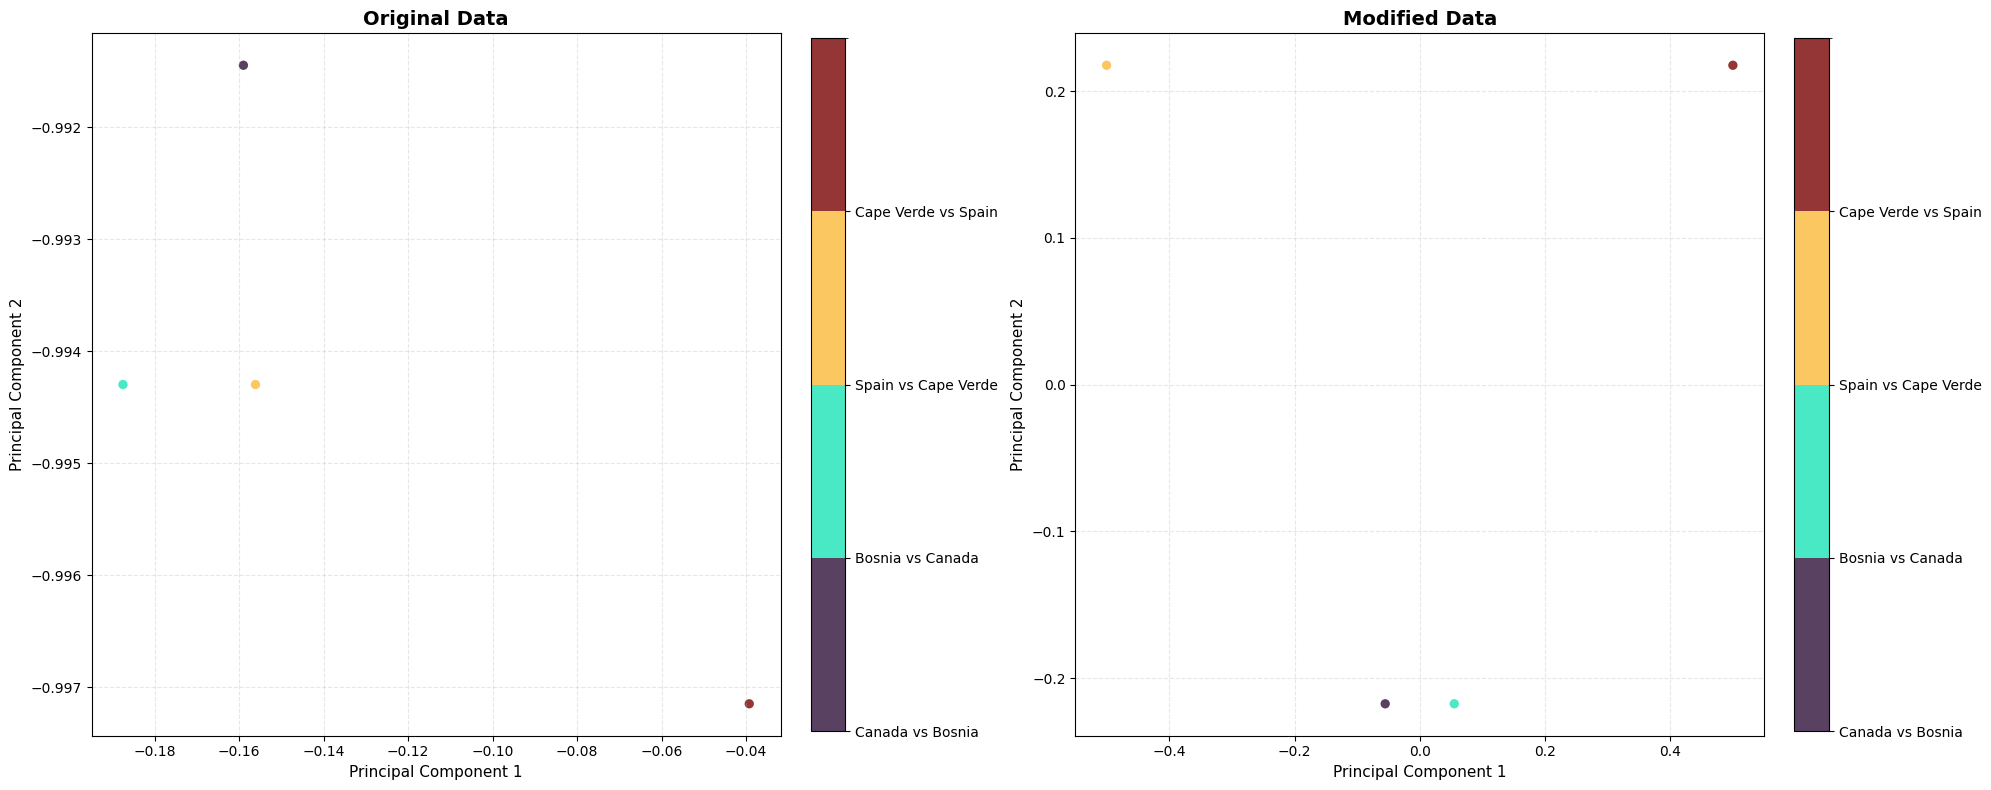

In [8]:
comparision_1_teams_modified = np.empty((0, 22))
for match in comparison_1_matchups:
    home_squad = match[0]
    away_squad = match[1]
    
    team = get_feature_to_predict_modified_2(
        mean_std=mean_std,
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        home_squad_id=home_squad,
        away_squad_id= away_squad,
        match_date='2026-06-15'
    )
    comparision_1_teams_modified = np.append(comparision_1_teams_modified, team.T, axis=0)

# Normalize
mean = np.mean(comparision_1_teams_modified, axis=(1,0), keepdims=True)
std = np.std(comparision_1_teams_modified, axis=(1,0), keepdims=True)
std = np.where(std == 0, 1.0, std)

comparision_1_teams_modified_normalized = (comparision_1_teams_modified - mean) / std

pca3 = PCA(n_components=2)
comparison_1_teams_modified_compressed = pca3.fit_transform(comparision_1_teams_modified_normalized)

plot_matchup_data_comparison(
    original=comparision_1_teams,
    modified=comparison_1_teams_modified_compressed,
    matchups=comparison_1_matchups
)

In [9]:
compare_teams(
    teams=comparision_1_teams_modified_normalized,
    match_abbreviations=comparison_1_matches,
    feature_names=["AGE", "FWD", "MID", "DEF", "GKP", "NUM", "FEW", "AVA", "EXP", "GOL", "AVG"]
)

        CvB      BvC      SvC      CvS
AGE  2.1497  2.0587  2.1588  2.5318
FWD  -0.5068  -0.5159  -0.5159  -0.5250
MID  -0.4977  -0.4977  -0.4886  -0.4886
DEF  -0.4977  -0.4977  -0.5068  -0.4977
GKP  -0.5250  -0.5250  -0.5250  -0.5250
NUM  -0.4158  -0.4704  -0.4249  -0.3976
FEW  -0.5250  -0.5341  -0.5341  -0.5341
AVA  -0.5341  -0.5341  -0.5250  -0.5341
EXP  -0.4431  -0.4340  -0.4431  -0.4340
GOL  1.9677  1.8222  2.3680  1.7676
AVG  -0.2674  -0.2921  -0.2054  -0.2069
AGE  2.0587  2.1497  2.5318  2.1588
FWD  -0.5159  -0.5068  -0.5250  -0.5159
MID  -0.4977  -0.4977  -0.4886  -0.4886
DEF  -0.4977  -0.4977  -0.4977  -0.5068
GKP  -0.5250  -0.5250  -0.5250  -0.5250
NUM  -0.4704  -0.4158  -0.3976  -0.4249
FEW  -0.5341  -0.5250  -0.5341  -0.5341
AVA  -0.5341  -0.5341  -0.5341  -0.5250
EXP  -0.4340  -0.4431  -0.4340  -0.4431
GOL  1.8222  1.9677  1.7676  2.3680
AVG  -0.2921  -0.2674  -0.2069  -0.2054


# Seeing Effect of Adding Offense and Defense in dataset

I'm thinking that I can show parameters having offense and defense and replace goal with them. This is because amount of goals contributed heavily to differences between match pair ups that had the same result. Finding a way to not use raw goals value could be good.

I can get offense and defense values from the following:

*Offense* - add up goals from the midfield and forwards in team OR add up goals of entire team OR combination of goals and appearances e.g addition of goals per appearances

*Defense* - add up appearances for defense and goalkeeper

## Results

For first experiment I use first method to calculate offense and method to calculate defense. Results are that 4 / 6 of the matches end up coming closer to each other which is an improvement (all apart Belgium vs Egypt). Result is in first_offense_defense.png.

For second experiment I make offense the same as goals and use same method to calculate defense. Results is that same 4 / 6 as above get close to each other but not as much as in first experiment. Result in second_offense_defense_png. Looks like defense definetly plays role in bringing items together and not including everyone in offense is also beneficial.

For third experiment I used third way to calculate offense i.e goals / appearance and the results were similar to first but the 2 that were seperated came closer to the cluster. This seems to be a better result

When applied to entire dataset: Some common elements are still grouped together though I am not sure if its better or worse than original. Will have to train model on it.

In [10]:
# Modified functions for getting player information, combining to team and getting value that will be used by model
def get_players_statistics_defense_offense(
    players: pd.DataFrame, 
    statistics: pd.DataFrame,
    player_id: str, 
    match_date: str
):
    """ 
    Return statistics for a player:
        1. age
        2. offense
        3. defense
        4. few appearances
        5. avg appearances
        6. many appearances
        7. num_tournaments
        8. average time per team
    
    Args:
        players (DataFrame): Dataframe with player information
        statistics (DataFrame): Dataframe with statistics of each player
        player_id (str): id of player
        match_date (str): day match was played
        
    Returns:
        x_i (ndarray): (1,8) array with statistics of each player
    """   
    FEW_APPEARANCES_THRESHOLD = 100
    AVG_APPEARANCES_THRESHOLD = 150
     
    player = players[players['ID'] == player_id]
    if len(player) < 1:
        return np.array([
            [0,0,0,0,0,0,0,0,0,0,0]
        ])
    
    # Age of player
    # raw_birthdate = player['birth_date'].iloc[0]
    birthdate = player['birth_date'].iloc[0]
    if (type(birthdate) == str):
        birthdate = datetime.strptime(birthdate.strip(), "%Y-%m-%d")
    tournament_date = datetime.strptime(match_date, "%Y-%m-%d")
    match_year = tournament_date.year
    difference_in_days = (tournament_date - birthdate).days
    age = int(difference_in_days / 365.25)
    
    forward = player['forward'].iloc[0]
    middlefielder = player['midfielder'].iloc[0]
    defense = player['defender'].iloc[0]
    goalkeeper = player['goalkeeper'].iloc[0]
    
    raw_tournaments = player['list_tournaments'].iloc[0].split(",")
    tournaments = [int(t) < match_year for t in raw_tournaments]
    num_tournaments = sum(tournaments)
    
    # Categorizing appearances
    few_appearances = 0
    avg_appearances = 0
    experienced = 0
    
    # Storing offense and defense
    offense = 0
    defense = 0
    
    appearances = 0
    goals = 0
    average_time_per_team = 0
    num_teams = 0
    player_statistics = statistics[statistics['id'] == player_id]
    
    if len(player_statistics) < 1:
        return np.array(
            [[age, offense, defense, few_appearances, avg_appearances, experienced, num_tournaments, average_time_per_team]]
        )
    
    # Get stats as per tournament year
    for stat in player_statistics.iterrows():
        s_from = stat[1]["from"]
        s_to = match_year if np.isnan(stat[1]["to"]) else stat[1]["to"]
        s_appearance = 0 if np.isnan(stat[1]['appearances']) else stat[1]['appearances']
        s_goals = 0 if np.isnan(stat[1]['goals']) else stat[1]['goals']
        
        
        if s_from < match_year and s_to < match_year:
            appearances += s_appearance
            goals += s_goals
            num_teams += 1
            average_time_per_team += s_to - s_from
        elif s_from < match_year:
            total = s_to - s_from
            num_years = match_year - s_from
            appearances += int(s_appearance * (num_years / total))
            goals += int(s_goals * (num_years / total))
            num_teams += 1
            average_time_per_team += num_years
            
    # Categorizing appearances
    if appearances < FEW_APPEARANCES_THRESHOLD:
        few_appearances = 1
    elif FEW_APPEARANCES_THRESHOLD <= appearances < AVG_APPEARANCES_THRESHOLD:
        avg_appearances = 1
    elif AVG_APPEARANCES_THRESHOLD <= appearances:
        experienced = 1
        
    # Getting offense and defense
    
    # Only getting offense if forward or midfield 
    # if (forward == 1 or middlefielder == 1):
    #     offense = goals
    # Make offense same as goals
    # offense = goals
    # Only getting offense if forward of midfield and making it average of semesters
    if (forward == 1 or middlefielder == 1):
        offense = goals / appearances if appearances > 0 else 0
    # If player is defense or goalkeeper represent defense as number of appearances
    if (goalkeeper == 1 or defense == 1):
        defense = appearances
            
    if num_teams == 0:
        average_time_per_team = 0
    else:
        average_time_per_team /= num_teams
        
    return np.array([
            [age, offense, defense, few_appearances, avg_appearances, experienced, num_tournaments, average_time_per_team]
    ]
        )
    
def get_team_statistics_defense_offense(
    statistics: pd.DataFrame,
    players: pd.DataFrame,
    squad_members: pd.DataFrame, 
    squad_id: int,
    match_date: str
):
    """ 
    This function should return a (11,8) vector with the statistics of the players in squad provided
    
    Args:
        statistics: Dataframe with statistics of each player
        players: Dataframe with details of players
        squad_members: Dataframe with ids of players in squad
        squad_id (scalar): identifier of squad playing
        match_date (str): Date of the match in YYYY-MM-dd
        
    Returns:
        team_statistics (ndarray): (11,11) vector with statistics of the players from the team
    """
    team_members = squad_members[squad_members["squad_id"] == squad_id].head(n=11)
    player_ids = team_members['player_id']
    if len(player_ids) != 11:
        raise Exception("Could not get players for team")
    
    player_ids = player_ids.tolist()
    team = np.empty((0,8))
    for p_id in player_ids:
        stats = get_players_statistics_defense_offense(players=players, statistics=statistics, player_id=p_id, match_date=match_date)
        team = np.append(team, stats, axis=0)
        
    return team

def get_feature_to_predict_defense_offense(
    mean_std: npt.NDArray,
    statistics: pd.DataFrame,
    players: pd.DataFrame,
    squad_members: pd.DataFrame,
    home_squad_id: int,
    away_squad_id: int,
    match_date: str
):
    """ 
    Get feature that I can use to make a prediction
    
    Args:
        mean_std: array with mean and std from training set
        statistics: dataframe with statistics of players
        players: dataframe with information of players
        squad_members: dataframe with players in a squad
        home_squad_id: Identifer of the squad for the home team
        away_squad_id: Identifer of the squad for the away team
        match_date: Date match is played in YYYY-MM-dd
        
    Returns:
        x (ndarray): a (18,1) array that has also been normalized
    """
    home_team = get_team_statistics_defense_offense(
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        squad_id=home_squad_id, 
        match_date=match_date
    )
    away_team = get_team_statistics_defense_offense(
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        squad_id=away_squad_id, 
        match_date=match_date
    )
    
    # Get sum of all members in each team
    sum_home_team = np.sum(home_team, axis=0)
    sum_away_team = np.sum(away_team, axis=0)
    
    
    # Concatenate
    sum_concated = (np.concatenate((sum_home_team, sum_away_team), axis=-1)).reshape((16, 1))
    
    # Normalize
    # mean = mean_std[0]
    # std = mean_std[0]
    
    # sum_normalized = (sum_concated - mean) / std
    
    return sum_concated

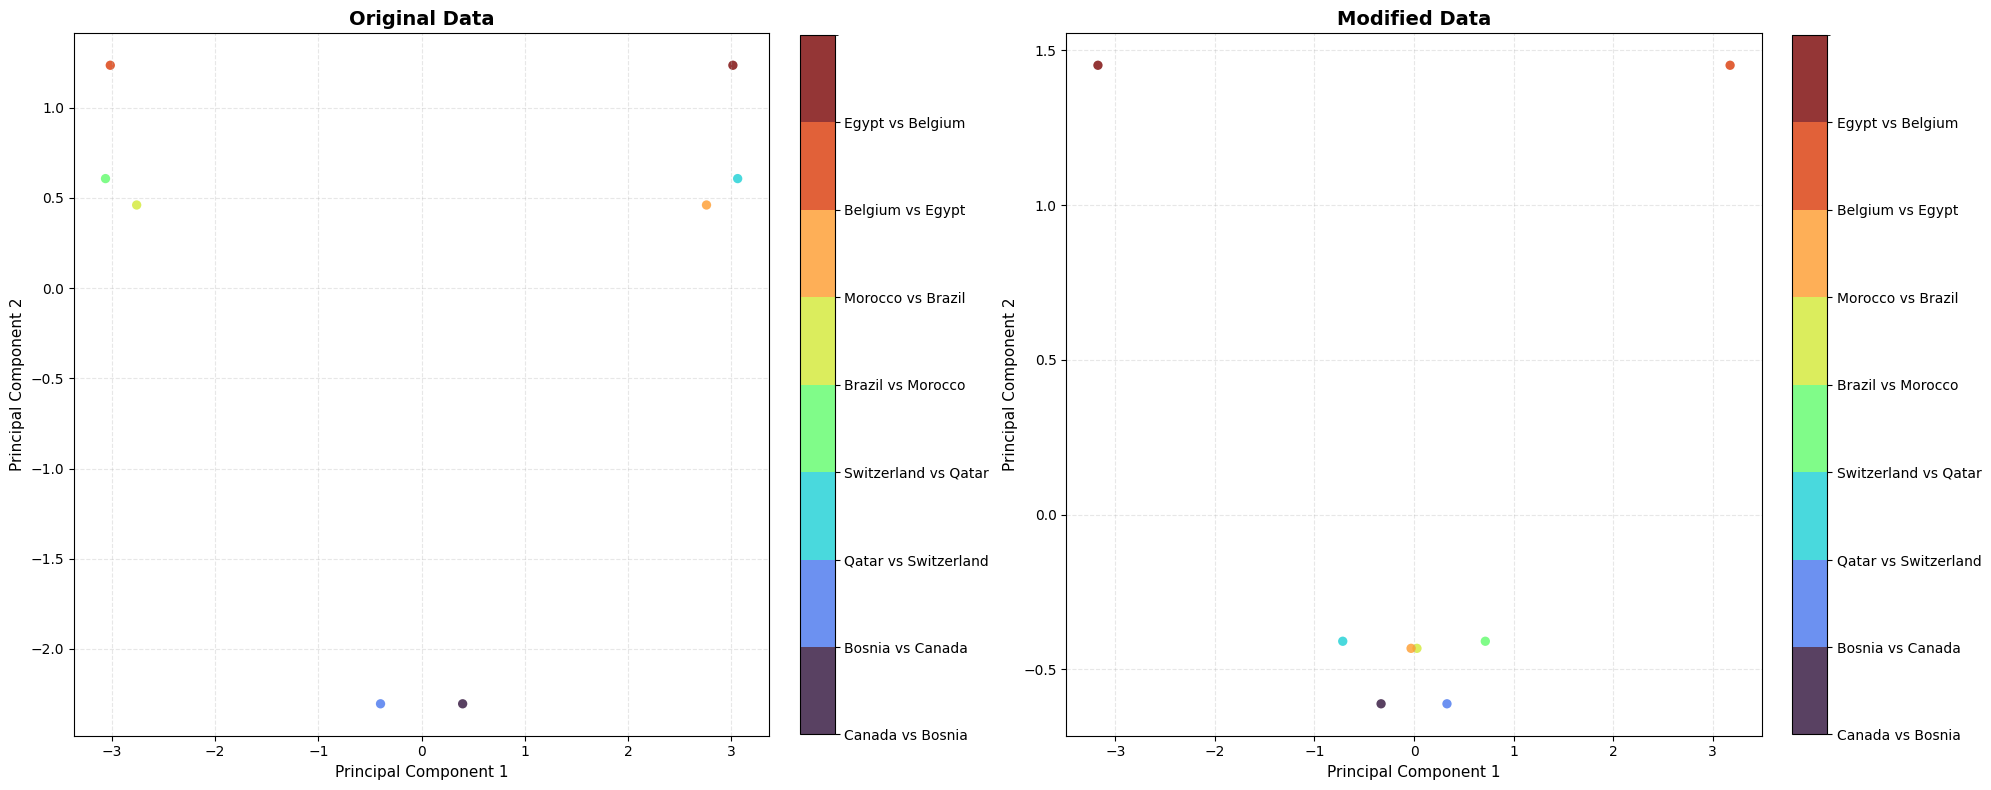

In [20]:
# Get all matches that ended 1-1
matches_end_1v1 = [
    (Squads.CANADA, Squads.BOSNIA), (Squads.BOSNIA, Squads.CANADA),
    (Squads.QATAR, Squads.SWITZERLAND), (Squads.SWITZERLAND, Squads.QATAR),
    (Squads.BRAZIL, Squads.MOROCCO), (Squads.MOROCCO, Squads.BRAZIL),
    (Squads.BELGIUM, Squads.EGYPT), (Squads.EGYPT, Squads.BELGIUM)
]

# Plot how the model would originally see these matches
original_1v1_matches = np.zeros((0,18))
defense_offense_1v1_matches = np.zeros((0,16))

for match in matches_end_1v1:
    home_squad = match[0]
    away_squad = match[1]
    
    team = get_feature_to_predict(
        mean_std=mean_std,
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        home_squad_id=home_squad,
        away_squad_id=away_squad,
        match_date="2026-06-15"
    )
    
    team_defense_offense = get_feature_to_predict_defense_offense(
        mean_std=mean_std,
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        home_squad_id=home_squad,
        away_squad_id=away_squad,
        match_date="2026-06-15"
    )
    
    original_1v1_matches = np.append(original_1v1_matches, team.T, axis=0) # Doing transpose so that matches match PCA
    defense_offense_1v1_matches = np.append(defense_offense_1v1_matches, team_defense_offense.T, axis=0)
    
pca_original = PCA(n_components=2)
compressed_original_1v1_matches = pca.fit_transform(original_1v1_matches)

# Normalize defense offense features
defense_offense_mean = np.mean(defense_offense_1v1_matches, axis=(1,0), keepdims=True)
defense_offense_std = np.std(defense_offense_1v1_matches, axis=(1,0), keepdims=True)
defense_offense_std = np.where(defense_offense_std == 0, 1.0, defense_offense_std)

defense_offense_matches_normalized = (defense_offense_1v1_matches - defense_offense_mean) / defense_offense_std

pca_defense_offense = PCA(n_components=2)
compressed_defense_offense_1v1 = pca_defense_offense.fit_transform(defense_offense_matches_normalized)

# Compare
plot_matchup_data_comparison(
    original=compressed_original_1v1_matches,
    modified=compressed_defense_offense_1v1,
    matchups=matches_end_1v1
)

Variance maintained for original dataset 0.9619979974830137
Variance maintained for offense defense dataset 0.8215053162348189


ValueError: 'c' argument has 20 elements, which is inconsistent with 'x' and 'y' with size 24.

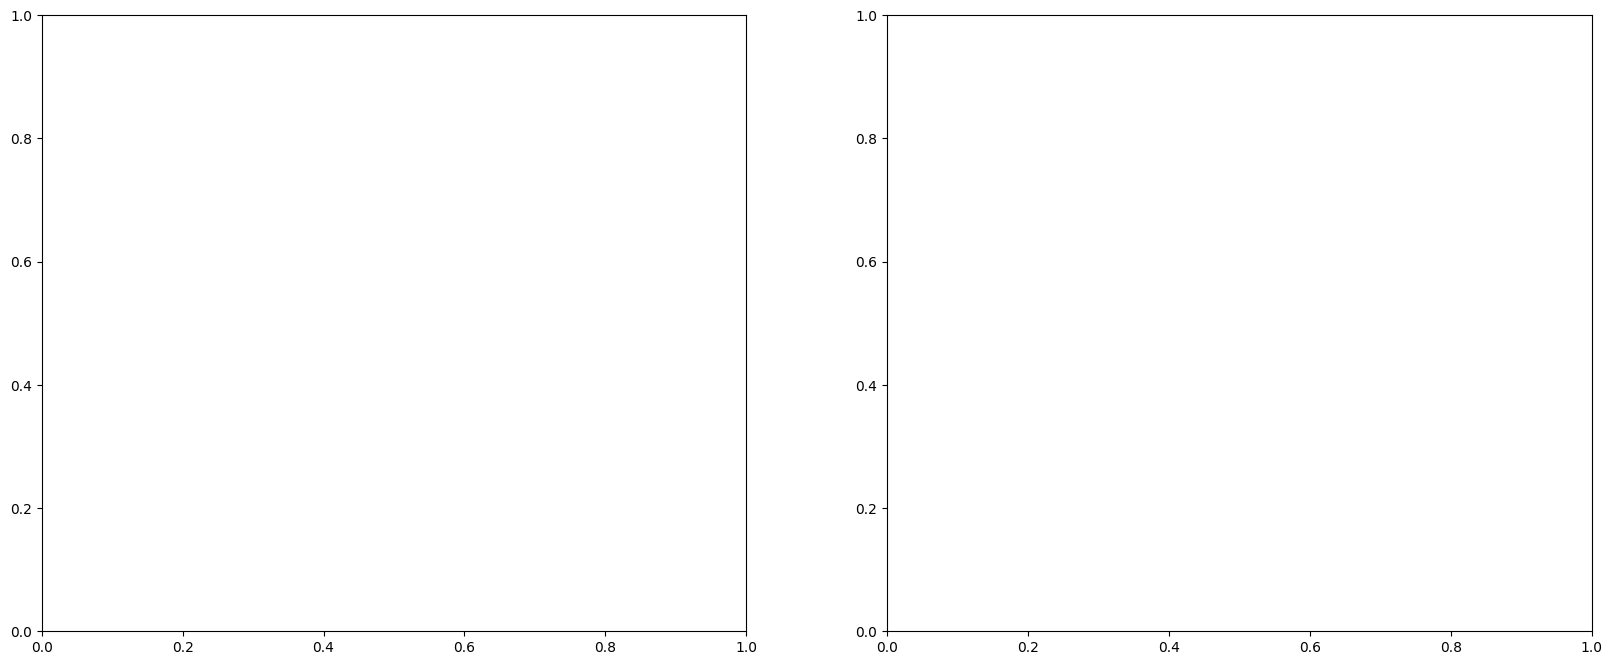

In [21]:
# See effect on the entire dataset
squads = 24
original_teams = np.empty((0, 18))
offense_defense_teams = np.empty((0, 16))
full_matchups = []

for i in range(0, squads - 1, 2):
    home_squad = i + 1
    away_squad = i + 2
    
    team = get_feature_to_predict(
        mean_std=mean_std,
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        home_squad_id=home_squad,
        away_squad_id= away_squad,
        match_date='2026-06-15'
    )
    team_offense_defense = get_feature_to_predict_defense_offense(
        mean_std=mean_std,
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        home_squad_id=home_squad,
        away_squad_id=away_squad,
        match_date='2026-06-15'
    )
    
    team_reversed = get_feature_to_predict(
        mean_std=mean_std,
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        home_squad_id=away_squad,
        away_squad_id= home_squad,
        match_date='2026-06-15'
    )
    team_offense_defense_reversed = get_feature_to_predict_defense_offense(
        mean_std=mean_std,
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        home_squad_id=away_squad,
        away_squad_id=home_squad,
        match_date='2026-06-15'
    )
    
    full_matchups.append((home_squad, away_squad))
    full_matchups.append((away_squad, home_squad))
    
    original_teams = np.append(original_teams, team.T, axis=0)
    original_teams = np.append(original_teams, team_reversed.T, axis=0)
    
    offense_defense_teams = np.append(offense_defense_teams, team_offense_defense.T, axis=0)
    offense_defense_teams = np.append(offense_defense_teams, team_offense_defense_reversed.T, axis=0)
    

pca_original_full = PCA(n_components=2)
original_compressed_teams = pca_original_full.fit_transform(original_teams)

print(f"Variance maintained for original dataset {np.sum(pca_original_full.explained_variance_ratio_)}")

pca_offense_defense_full = PCA(n_components=2)
offense_defense_full_compressed = pca_offense_defense_full.fit_transform(offense_defense_teams)

print(f"Variance maintained for offense defense dataset {np.sum(pca_offense_defense_full.explained_variance_ratio_)}")

plot_matchup_data_comparison(
    original=original_compressed_teams,
    modified=offense_defense_full_compressed,
    feature_names=actual_scores
)

# Trying to make 1 v 1 examples the same

(6, 2)


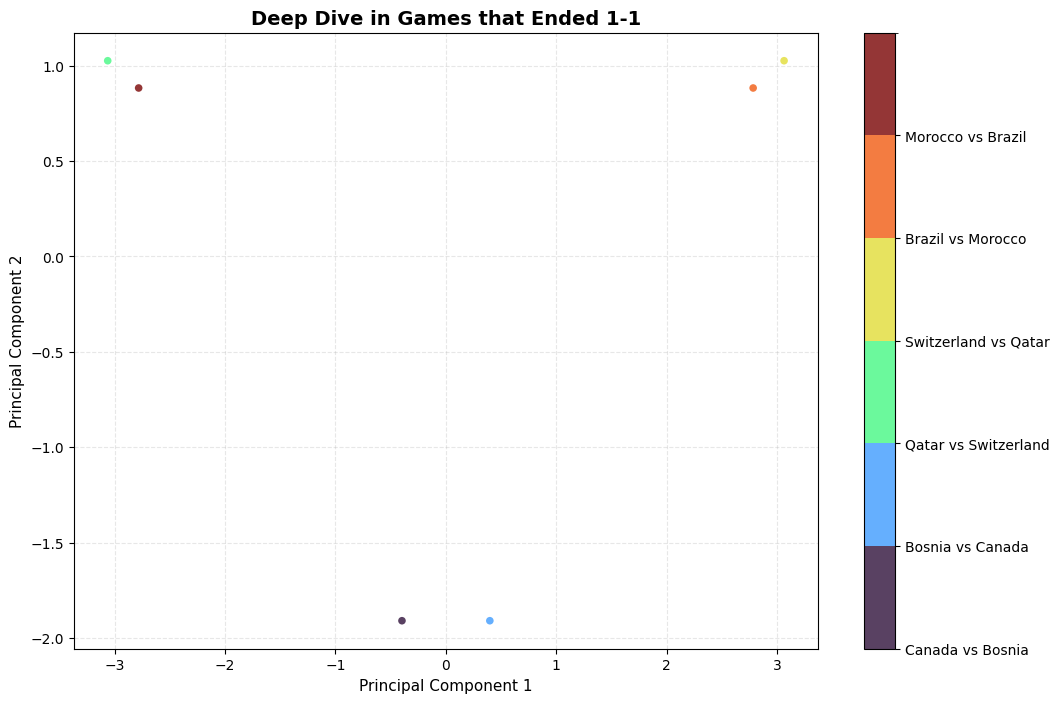

In [13]:
# Deep dive into 1-1 actual score examples

# Store home away id of teams that ended 1-1
matchups = [
    (Squads.CANADA, Squads.BOSNIA), (Squads.BOSNIA, Squads.CANADA),
    (Squads.QATAR, Squads.SWITZERLAND), (Squads.SWITZERLAND, Squads.QATAR),
    (Squads.BRAZIL, Squads.MOROCCO), (Squads.MOROCCO, Squads.BRAZIL)
]
        
feature_names = [f"{squad_id_to_country(i[0])} vs {squad_id_to_country(i[1])}" for i in matchups]
num_categories = len(feature_names)
cmap = plt.get_cmap('turbo', num_categories) # Forces the map into distinct steps
norm = mcolors.BoundaryNorm(boundaries=range(num_categories + 1), ncolors=num_categories)

# Get features to predict for each of home away pairings
unnormalized_teams = np.empty((0, 18))
for match in matchups:
    home_squad = match[0]
    away_squad = match[1]
    
    team = get_feature_to_predict(
        mean_std=mean_std,
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        home_squad_id=home_squad,
        away_squad_id= away_squad,
        match_date='2026-06-15'
    )
    
    unnormalized_teams = np.append(unnormalized_teams, team.T, axis=0)

# Compress with PCA
compressed_teams = pca.fit_transform(unnormalized_teams)
print(compressed_teams.shape)

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(
    compressed_teams[:, 0], 
    compressed_teams[:, 1], 
    c=list(range(len(feature_names))), 
    cmap=cmap,
    norm=norm,
    alpha=0.8, 
    edgecolors='none',
    s=30
)

# Repeat the same step here so the actual scores match the exact same scale
cbar = plt.colorbar()
cbar.set_ticks(range(len(feature_names)))
cbar.set_ticklabels(feature_names)

plt.title('Deep Dive in Games that Ended 1-1', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=11)
plt.ylabel('Principal Component 2', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


In [14]:
# Display values in the teams
print(unnormalized_teams.shape)

num_matches = unnormalized_teams.shape[0]
num_features = unnormalized_teams.shape[1]
print("      CvB        BvC      QvS      SvQ      BvM      MvB")

for j in range(2):
    age_position = (9*j)
    forward_position = age_position + 1
    midfielder_position = forward_position + 1
    defense_position = midfielder_position + 1
    goalkeeper_position = defense_position + 1
    num_tournaments_position = goalkeeper_position + 1
    appearance_position = num_tournaments_position + 1
    goals_position = appearance_position + 1
    avg_time = goals_position +  1
    
    print(f"AGE  {unnormalized_teams[0, age_position]:.4f}  {unnormalized_teams[1, age_position]:.4f}  {unnormalized_teams[2, age_position]:.4f}  {unnormalized_teams[3, age_position]:.4f}  {unnormalized_teams[4, age_position]:.4f}  {unnormalized_teams[5, age_position]:.4f}")
    print(f"FWD  {unnormalized_teams[0, forward_position]:.4f}  {unnormalized_teams[1, forward_position]:.4f}  {unnormalized_teams[2, forward_position]:.4f}  {unnormalized_teams[3, forward_position]:.4f}  {unnormalized_teams[4, forward_position]:.4f}  {unnormalized_teams[5, forward_position]:.4f}")
    print(f"MID  {unnormalized_teams[0, midfielder_position]:.4f}  {unnormalized_teams[1, midfielder_position]:.4f}  {unnormalized_teams[2, midfielder_position]:.4f}  {unnormalized_teams[3, midfielder_position]:.4f}  {unnormalized_teams[4, midfielder_position]:.4f}  {unnormalized_teams[5, midfielder_position]:.4f}")
    print(f"DEF  {unnormalized_teams[0, defense_position]:.4f}  {unnormalized_teams[1, defense_position]:.4f}  {unnormalized_teams[2, defense_position]:.4f}  {unnormalized_teams[3, defense_position]:.4f}  {unnormalized_teams[4, defense_position]:.4f}  {unnormalized_teams[5, defense_position]:.4f}")
    print(f"GKP  {unnormalized_teams[0, goalkeeper_position]:.4f}  {unnormalized_teams[1, goalkeeper_position]:.4f}  {unnormalized_teams[2, goalkeeper_position]:.4f}  {unnormalized_teams[3, goalkeeper_position]:.4f}  {unnormalized_teams[4, goalkeeper_position]:.4f}  {unnormalized_teams[5, goalkeeper_position]:.4f}")
    print(f"NUM  {unnormalized_teams[0, num_tournaments_position]:.4f}  {unnormalized_teams[1, num_tournaments_position]:.4f}  {unnormalized_teams[2, num_tournaments_position]:.4f}  {unnormalized_teams[3, num_tournaments_position]:.4f}  {unnormalized_teams[4, num_tournaments_position]:.4f}  {unnormalized_teams[5, num_tournaments_position]:.4f}")
    print(f"APP  {unnormalized_teams[0, appearance_position]:.4f}  {unnormalized_teams[1, appearance_position]:.4f}  {unnormalized_teams[2, appearance_position]:.4f}  {unnormalized_teams[3, appearance_position]:.4f}  {unnormalized_teams[4, appearance_position]:.4f}  {unnormalized_teams[5, appearance_position]:.4f}")
    print(f"GOL  {unnormalized_teams[0, goals_position]:.4f}  {unnormalized_teams[1, goals_position]:.4f}  {unnormalized_teams[2, goals_position]:.4f}  {unnormalized_teams[3, goals_position]:.4f}  {unnormalized_teams[4, goals_position]:.4f}  {unnormalized_teams[5, goals_position]:.4f}")
    print(f"AVG  {unnormalized_teams[0, avg_time]:.4f}  {unnormalized_teams[1, avg_time]:.4f}  {unnormalized_teams[2, avg_time]:.4f}  {unnormalized_teams[3, avg_time]:.4f}  {unnormalized_teams[4, avg_time]:.4f}  {unnormalized_teams[5, avg_time]:.4f}")


(6, 18)
      CvB        BvC      QvS      SvQ      BvM      MvB
AGE  -0.1590  -0.1875  -0.0763  -0.0792  -0.0877  -0.1961
FWD  -0.9914  -0.9943  -0.9943  -0.9971  -0.9943  -0.9971
MID  -0.9886  -0.9886  -0.9886  -0.9857  -0.9914  -0.9857
DEF  -0.9886  -0.9886  -0.9886  -0.9886  -0.9857  -0.9886
GKP  -0.9971  -0.9971  -0.9971  -0.9971  -0.9971  -0.9971
NUM  -0.9629  -0.9800  -0.9572  -0.9430  -0.9544  -0.9743
APP  4.6932  5.2605  4.8642  9.2204  8.8868  4.9982
GOL  -0.2160  -0.2616  0.0548  -0.1790  0.3713  -0.4669
AVG  -0.9165  -0.9242  -0.8092  -0.9063  -0.8830  -0.9144
AGE  -0.1875  -0.1590  -0.0792  -0.0763  -0.1961  -0.0877
FWD  -0.9943  -0.9914  -0.9971  -0.9943  -0.9971  -0.9943
MID  -0.9886  -0.9886  -0.9857  -0.9886  -0.9857  -0.9914
DEF  -0.9886  -0.9886  -0.9886  -0.9886  -0.9886  -0.9857
GKP  -0.9971  -0.9971  -0.9971  -0.9971  -0.9971  -0.9971
NUM  -0.9800  -0.9629  -0.9430  -0.9572  -0.9743  -0.9544
APP  5.2605  4.6932  9.2204  4.8642  4.9982  8.8868
GOL  -0.2616  -0.2160

# Experimenting different sets of data

In [15]:
from datetime import datetime
import numpy.typing as npt

In [16]:
def get_players_statistics_modified(
    players: pd.DataFrame, 
    statistics: pd.DataFrame,
    player_id: str, 
    match_date: str
):
    """ 
    Return statistics for a player:
        1. young
        2. prime
        3. old
        4. num_tournaments
        5. few appearances
        6. average apperances
        7. many appearances
        8. goals
        9. average time per team
    
    Args:
        players (DataFrame): Dataframe with player information
        statistics (DataFrame): Dataframe with statistics of each player
        player_id (str): id of player
        match_date (str): day match was played
        
    Returns:
        x_i (ndarray): (1,9) array with statistics of each player
    """    
    FEW_APPEARANCE_THRESHOLD = 100
    AVG_APPEARANCE_THRESHOLD = 200
    
    YOUNG_THRESHOLD = 23
    PRIME_THRESHOLD = 32
    
    
    player = players[players['ID'] == player_id]
    if len(player) < 1:
        return np.array([
            [0,0,0,0,0,0,0]
        ])
    
    # Age of player
    # raw_birthdate = player['birth_date'].iloc[0]
    birthdate = player['birth_date'].iloc[0]
    if (type(birthdate) == str):
        birthdate = datetime.strptime(birthdate.strip(), "%Y-%m-%d")
    tournament_date = datetime.strptime(match_date, "%Y-%m-%d")
    match_year = tournament_date.year
    difference_in_days = (tournament_date - birthdate).days
    age = int(difference_in_days / 365.25)
    
    # Splitting age into categorical features
    young = 0
    prime = 0
    old = 0
    if age < YOUNG_THRESHOLD:
        young = 1
    elif YOUNG_THRESHOLD <= age < PRIME_THRESHOLD:
        prime = 1
    elif age >= PRIME_THRESHOLD:
        old = 1
    
    forward = player['forward'].iloc[0]
    middlefielder = player['midfielder'].iloc[0]
    defense = player['defender'].iloc[0]
    goalkeeper = player['goalkeeper'].iloc[0]
    
    raw_tournaments = player['list_tournaments'].iloc[0].split(",")
    tournaments = [int(t) < match_year for t in raw_tournaments]
    num_tournaments = sum(tournaments)
    
    # Splitting appearances into categorical features
    appearances = 0
    few_appearances = 0
    avg_appearances = 0
    many_appearances = 0
    goals = 0
    average_time_per_team = 0
    num_teams = 0
    player_statistics = statistics[statistics['id'] == player_id]
    
    if len(player_statistics) < 1:
        return np.array(
            [[young, prime, old, num_tournaments, few_appearances, avg_appearances, many_appearances, goals, average_time_per_team]]
        )
    
    # Get stats as per tournament year
    for stat in player_statistics.iterrows():
        s_from = stat[1]["from"]
        s_to = match_year if np.isnan(stat[1]["to"]) else stat[1]["to"]
        s_appearance = 0 if np.isnan(stat[1]['appearances']) else stat[1]['appearances']
        s_goals = 0 if np.isnan(stat[1]['goals']) else stat[1]['goals']
        
        
        if s_from < match_year and s_to < match_year:
            appearances += s_appearance
            goals += s_goals
            num_teams += 1
            average_time_per_team += s_to - s_from
        elif s_from < match_year:
            total = s_to - s_from
            num_years = match_year - s_from
            appearances += int(s_appearance * (num_years / total))
            goals += int(s_goals * (num_years / total))
            num_teams += 1
            average_time_per_team += num_years
            
            
            
    if num_teams == 0:
        average_time_per_team = 0
    else:
        average_time_per_team /= num_teams
        
    # Splitting appearances into categorical features
    if appearances < FEW_APPEARANCE_THRESHOLD:
        few_appearances = 1
    elif FEW_APPEARANCE_THRESHOLD <= appearances < AVG_APPEARANCE_THRESHOLD:
        avg_appearances = 1
    elif appearances >= AVG_APPEARANCE_THRESHOLD:
        many_appearances = 1
        
    return np.array([
            [young, prime, old, num_tournaments, few_appearances, avg_appearances, many_appearances, goals, average_time_per_team]
    ]
        )
    
def get_team_statistics_from_squad_modified(
    statistics: pd.DataFrame,
    players: pd.DataFrame,
    squad_members: pd.DataFrame, 
    squad_id: int,
    match_date: str
):
    """ 
    This function should return a (11,9) vector with the statistics of the players in squad provided
    
    Args:
        statistics: Dataframe with statistics of each player
        players: Dataframe with details of players
        squad_members: Dataframe with ids of players in squad
        squad_id (scalar): identifier of squad playing
        match_date (str): Date of the match in YYYY-MM-dd
        
    Returns:
        team_statistics (ndarray): (11,9) vector with statistics of the players from the team
    """
    team_members = squad_members[squad_members["squad_id"] == squad_id].head(n=11)
    player_ids = team_members['player_id']
    if len(player_ids) != 11:
        raise Exception("Could not get players for team")
    
    player_ids = player_ids.tolist()
    team = np.empty((0,9))
    for p_id in player_ids:
        stats = get_players_statistics_modified(players=players, statistics=statistics, player_id=p_id, match_date=match_date)
        team = np.append(team, stats, axis=0)
        
    return team

def get_feature_to_predict_modified(
    mean_std: npt.NDArray,
    statistics: pd.DataFrame,
    players: pd.DataFrame,
    squad_members: pd.DataFrame,
    home_squad_id: int,
    away_squad_id: int,
    match_date: str
):
    """ 
    Get feature that I can use to make a prediction
    
    Args:
        mean_std: array with mean and std from training set
        statistics: dataframe with statistics of players
        players: dataframe with information of players
        squad_members: dataframe with players in a squad
        home_squad_id: Identifer of the squad for the home team
        away_squad_id: Identifer of the squad for the away team
        match_date: Date match is played in YYYY-MM-dd
        
    Returns:
        x (ndarray): a (18,1) array that has also been normalized
    """
    home_team = get_team_statistics_from_squad_modified(
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        squad_id=home_squad_id, 
        match_date=match_date
    )
    away_team = get_team_statistics_from_squad_modified(
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        squad_id=away_squad_id, 
        match_date=match_date
    )
    
    # Get sum of all members in each team
    sum_home_team = np.sum(home_team, axis=0)
    sum_away_team = np.sum(away_team, axis=0)
    
    goals_position = 7
    home_team_goals = sum_home_team[goals_position]
    away_team_goals = sum_away_team[goals_position]
    
    
    # Concatenate
    sum_concated = (np.concatenate((sum_home_team, sum_away_team), axis=-1)).reshape((18, 1))
    
    sum_concated[goals_position] -= away_team_goals
    sum_concated[goals_position + 9] -= home_team_goals
    
    
    # Normalize
    # mean = mean_std[0]
    # std = mean_std[0]
    
    # sum_normalized = (sum_concated - mean) / std
    
    return sum_concated

(6, 18)
0.9972155000374721
(6, 2)


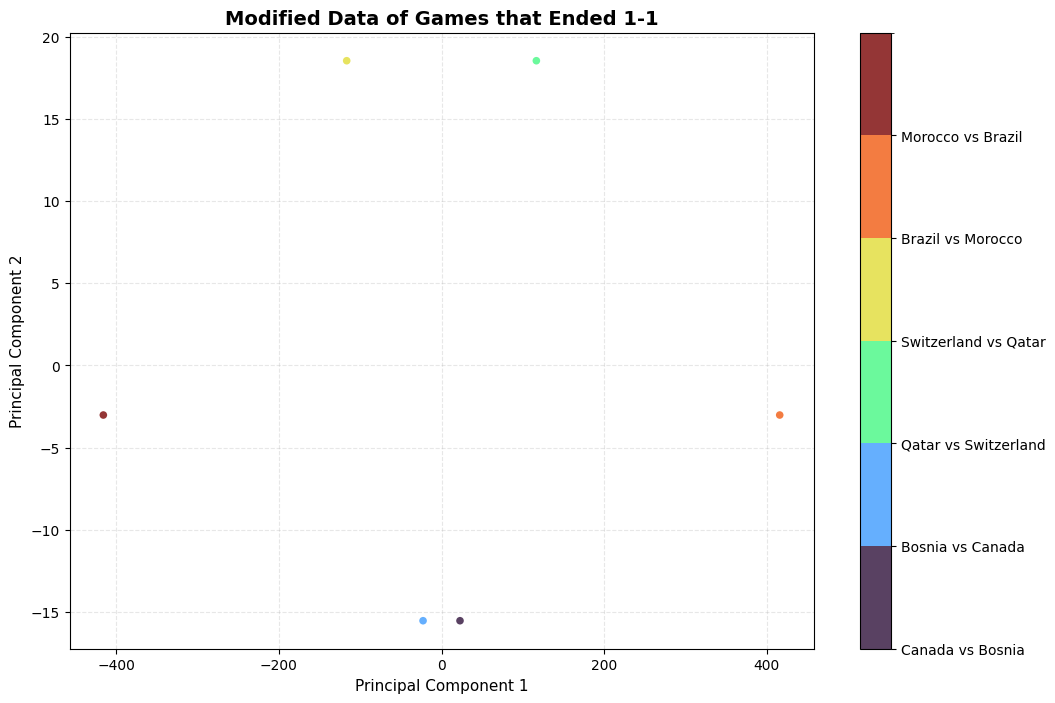

In [17]:
unnormalized_teams = np.empty((0, 18))
for match in matchups:
    home_squad = match[0]
    away_squad = match[1]
    
    team = get_feature_to_predict_modified(
        mean_std=mean_std,
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        home_squad_id=home_squad,
        away_squad_id= away_squad,
        match_date='2026-06-15'
    )
    
    unnormalized_teams = np.append(unnormalized_teams, team.T, axis=0)
    
print(unnormalized_teams.shape)

# Normalize
mean = np.mean(unnormalized_teams, axis=(1,0), keepdims=True)
std = np.std(unnormalized_teams, axis=(1,0), keepdims=True)
std = np.where(std == 0, 1.0, std)

teams = (unnormalized_teams - mean) / std

# PCA compression
pca2 = PCA(n_components=2)
compressed_teams_modified = pca2.fit_transform(unnormalized_teams)
print(np.sum(pca2.explained_variance_ratio_))
print(compressed_teams.shape)

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(
    compressed_teams_modified[:, 0], 
    compressed_teams_modified[:, 1], 
    c=list(range(len(feature_names))), 
    cmap=cmap,
    norm=norm,
    alpha=0.8, 
    edgecolors='none',
    s=30
)

# Repeat the same step here so the actual scores match the exact same scale
cbar = plt.colorbar()
cbar.set_ticks(range(len(feature_names)))
cbar.set_ticklabels(feature_names)

plt.title('Modified Data of Games that Ended 1-1', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=11)
plt.ylabel('Principal Component 2', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [18]:
# Print actual values
print("      CvB        BvC      QvS      SvQ      BvM      MvB")

for j in range(2):
    young_position = (7*j)
    prime_position = young_position + 1
    old_position = prime_position + 1
    num_tournaments_position = old_position + 1
    few_app_position = num_tournaments_position + 1
    avg_app_position = few_app_position + 1
    many_app_position = avg_app_position + 1
    goals_position = many_app_position + 1
    avg_time = goals_position +  1
    
    print(f"YNG  {teams[0, young_position]:.4f}  {teams[1, young_position]:.4f}  {teams[2, young_position]:.4f}  {teams[3, young_position]:.4f}  {teams[4, young_position]:.4f}  {teams[5, young_position]:.4f}")
    print(f"PRI  {teams[0, prime_position]:.4f}  {teams[1, prime_position]:.4f}  {teams[2, prime_position]:.4f}  {teams[3, prime_position]:.4f}  {teams[4, prime_position]:.4f}  {teams[5, prime_position]:.4f}")
    print(f"OLD  {teams[0, old_position]:.4f}  {teams[1, old_position]:.4f}  {teams[2, old_position]:.4f}  {teams[3, old_position]:.4f}  {teams[4, old_position]:.4f}  {teams[5, old_position]:.4f}")
    print(f"NUM  {teams[0, num_tournaments_position]:.4f}  {teams[1, num_tournaments_position]:.4f}  {teams[2, num_tournaments_position]:.4f}  {teams[3, num_tournaments_position]:.4f}  {teams[4, num_tournaments_position]:.4f}  {teams[5, num_tournaments_position]:.4f}")
    print(f"FEW  {teams[0, few_app_position]:.4f}  {teams[1, few_app_position]:.4f}  {teams[2, few_app_position]:.4f}  {teams[3, few_app_position]:.4f}  {teams[4, few_app_position]:.4f}  {teams[5, few_app_position]:.4f}")
    print(f"AVA  {teams[0, avg_app_position]:.4f}  {teams[1, avg_app_position]:.4f}  {teams[2, avg_app_position]:.4f}  {teams[3, avg_app_position]:.4f}  {teams[4, avg_app_position]:.4f}  {teams[5, avg_app_position]:.4f}")
    print(f"MAN  {teams[0, many_app_position]:.4f}  {teams[1, many_app_position]:.4f}  {teams[2, many_app_position]:.4f}  {teams[3, many_app_position]:.4f}  {teams[4, many_app_position]:.4f}  {teams[5, many_app_position]:.4f}")
    print(f"GOL  {teams[0, goals_position]:.4f}  {teams[1, goals_position]:.4f}  {teams[2, goals_position]:.4f}  {teams[3, goals_position]:.4f}  {teams[4, goals_position]:.4f}  {teams[5, goals_position]:.4f}")
    print(f"AVG  {teams[0, avg_time]:.4f}  {teams[1, avg_time]:.4f}  {teams[2, avg_time]:.4f}  {teams[3, avg_time]:.4f}  {teams[4, avg_time]:.4f}  {teams[5, avg_time]:.4f}")


      CvB        BvC      QvS      SvQ      BvM      MvB
YNG  -0.1186  -0.1186  -0.1186  -0.1186  -0.1352  -0.0853
PRI  0.0146  0.0146  -0.0354  -0.0354  -0.0187  -0.0187
OLD  -0.1186  -0.1186  -0.0687  -0.0687  -0.0687  -0.1186
NUM  0.0811  -0.0187  0.1144  0.1976  0.1311  0.0146
FEW  -0.1186  -0.1352  -0.0853  -0.1186  -0.1352  -0.1019
AVA  -0.0520  -0.0354  -0.0853  -0.1352  -0.1186  -0.0687
MAN  -0.0520  -0.0520  -0.0520  0.0312  0.0312  -0.0520
GOL  0.1311  -0.4015  1.2295  -1.4999  4.7578  -5.0282
AVG  0.3525  0.3075  0.9787  0.4119  0.5475  0.3644
YNG  0.1311  -0.4015  1.2295  -1.4999  4.7578  -5.0282
PRI  0.3525  0.3075  0.9787  0.4119  0.5475  0.3644
OLD  -0.1186  -0.1186  -0.1186  -0.1186  -0.0853  -0.1352
NUM  0.0146  0.0146  -0.0354  -0.0354  -0.0187  -0.0187
FEW  -0.1186  -0.1186  -0.0687  -0.0687  -0.1186  -0.0687
AVA  -0.0187  0.0811  0.1976  0.1144  0.0146  0.1311
MAN  -0.1352  -0.1186  -0.1186  -0.0853  -0.1019  -0.1352
GOL  -0.0354  -0.0520  -0.1352  -0.0853  -0.0687 

(20, 18)
(20, 2)
0.9984426693119097


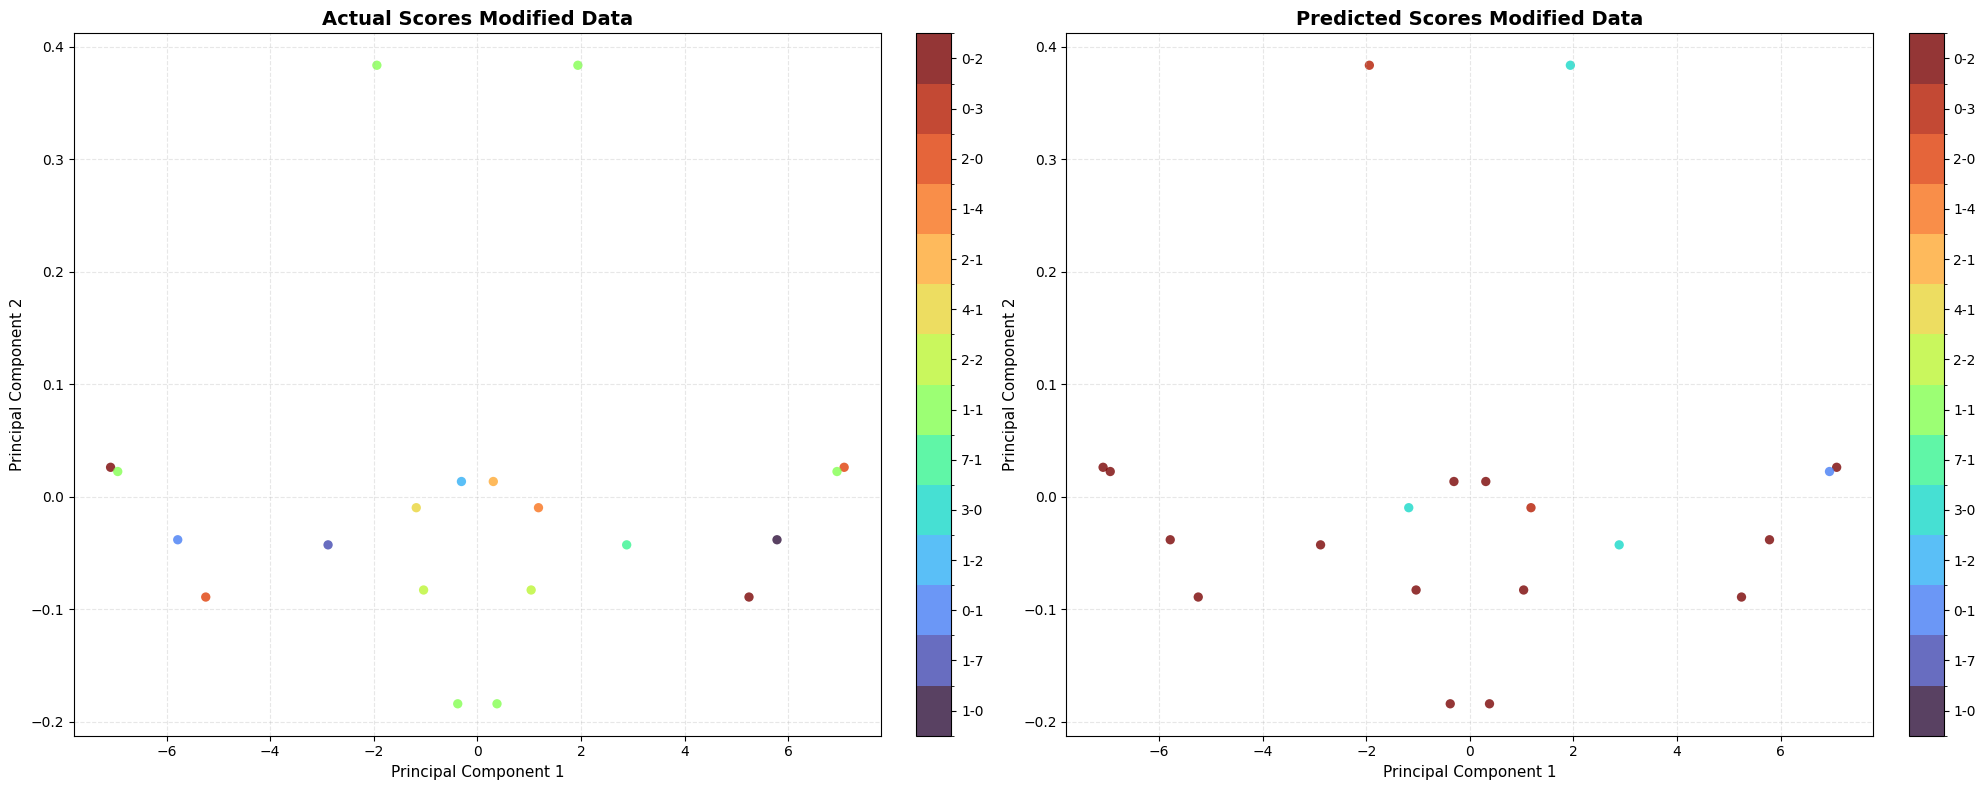

In [19]:
# See how changes affect the rest of the matches
squads = 20
unnormalized_teams = np.empty((0, 18))

for i in range(0, squads - 1, 2):
    home_squad = i + 1
    away_squad = i + 2
    
    team = get_feature_to_predict_modified(
        mean_std=mean_std,
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        home_squad_id=home_squad,
        away_squad_id= away_squad,
        match_date='2026-06-15'
    )
    team_reversed = get_feature_to_predict_modified(
        mean_std=mean_std,
        statistics=statistics,
        players=players,
        squad_members=squad_members,
        home_squad_id=away_squad,
        away_squad_id= home_squad,
        match_date='2026-06-15'
    )
    unnormalized_teams = np.append(unnormalized_teams, team.T, axis=0)
    unnormalized_teams = np.append(unnormalized_teams, team_reversed.T, axis=0)
    
print(unnormalized_teams.shape)

# Normalize
mean = np.mean(unnormalized_teams, axis=(1,0), keepdims=True)
std = np.std(unnormalized_teams, axis=(1,0), keepdims=True)
std = np.where(std == 0, 1.0, std)

teams = (unnormalized_teams - mean) / std

pca3 = PCA(n_components=2)
compressed_teams_3 = pca3.fit_transform(teams)
print(compressed_teams_3.shape)
print(np.sum(pca3.explained_variance_ratio_))

predicted_scores = [
    '0-2',
    '0-2',
    '0-2',
    '0-2',
    '0-2',
    '0-2',
    '3-0',
    '0-3',
    '3-0',
    '0-3',
    '0-1',
    '0-2',
    '0-2',
    '0-2',
    '3-0',
    '0-2',
    '0-2',
    '0-2',
    '0-2',
    '0-2',
]

actual_scores = [
    '2-0',
    '0-2',
    '2-1',
    '1-2',
    '1-1',
    '1-1',
    '4-1',
    '1-4',
    '1-1',
    '1-1',
    '1-1',
    '1-1',
    '0-1',
    '1-0',
    '7-1',
    '1-7',
    '2-0',
    '0-2',
    '2-2',
    '2-2'
]
total_scores = []
total_scores.extend(predicted_scores)
total_scores.extend(actual_scores)

feature_names = list(set(total_scores))

predicted_scores_color_map = [feature_names.index(i) for i in predicted_scores]
actual_scores_color_map = [feature_names.index(i) for i in actual_scores]

# Put this block right above your plt.scatter call
num_categories = len(feature_names)
cmap = plt.get_cmap('turbo', num_categories) # Forces the map into distinct steps
norm = mcolors.BoundaryNorm(boundaries=range(num_categories + 1), ncolors=num_categories)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(20, 8))

# ==========================================
# Right PLOT: Predicted Scores (axs[0])
# ==========================================
scatter1 = axs[1].scatter(
    compressed_teams_3[:, 0],
    compressed_teams_3[:, 1],
    c=predicted_scores_color_map,
    cmap=cmap,
    norm=norm,
    alpha=0.8,
    edgecolors="none",
    s=45,  # Slightly larger for visibility
)
axs[1].set_title("Predicted Scores Modified Data", fontsize=14, fontweight="bold")
axs[1].set_xlabel("Principal Component 1", fontsize=11)
axs[1].set_ylabel("Principal Component 2", fontsize=11)
axs[1].grid(True, linestyle="--", alpha=0.3)

# Add the categorical colorbar to the first plot
cbar1 = fig.colorbar(scatter1, ax=axs[1], fraction=0.046, pad=0.04)
cbar1.set_ticks(np.arange(num_categories) + 0.5)  # Centers text on color blocks
cbar1.set_ticklabels(feature_names)

# ==========================================
# RIGHT PLOT: Actual Scores (axs[1])
# ==========================================
scatter2 = axs[0].scatter(
    compressed_teams_3[:, 0],
    compressed_teams_3[:, 1],
    c=actual_scores_color_map,
    cmap=cmap,
    norm=norm,
    alpha=0.8,
    edgecolors="none",
    s=45,
)
axs[0].set_title("Actual Scores Modified Data", fontsize=14, fontweight="bold")
axs[0].set_xlabel("Principal Component 1", fontsize=11)
axs[0].set_ylabel("Principal Component 2", fontsize=11)
axs[0].grid(True, linestyle="--", alpha=0.3)

# Add the identical categorical colorbar to the second plot
cbar2 = fig.colorbar(scatter2, ax=axs[0], fraction=0.046, pad=0.04)
cbar2.set_ticks(np.arange(num_categories) + 0.5)
cbar2.set_ticklabels(feature_names)

# 3. Clean up spacing and render
plt.tight_layout()
plt.show()